In [2]:
from google.colab import files

uploaded = files.upload()

Saving upi_transactions_4000.csv to upi_transactions_4000 (1).csv


In [3]:
import pandas as pd

df = pd.read_csv("upi_transactions_4000.csv")

df.head(5)

,Transaction_ID,Date,Time,Sender_Bank,Receiver_Bank,UPI_App,Transaction_Type,Amount_INR,Status,Failure_Reason,City,Device_Type,Response_Time_ms,Is_Weekend
0,UPI100000001,2025-04-13,04:23:15,Union Bank,Canara Bank,Amazon Pay,Merchant Payment,264.44,Failed,Duplicate Transaction,Ahmedabad,iOS,374,True
1,UPI100000002,2025-12-26,04:27:03,ICICI,Kotak Mahindra,Amazon Pay,P2M,1930.19,Reversed,Bank Server Down,Kolkata,Android,818,False
2,UPI100000003,2025-11-10,07:58:13,IDBI Bank,Yes Bank,Google Pay,Bill Payment,1429.56,Failed,Account Blocked/Frozen,Kolkata,iOS,261,False
3,UPI100000004,2025-06-24,09:56:13,ICICI,IDBI Bank,CRED,Recharge,1356.26,Failed,Incorrect UPI PIN,Pune,Android,528,False
4,UPI100000005,2025-10-01,02:57:07,Yes Bank,IDBI Bank,WhatsApp Pay,P2M,740.22,Failed,Bank Server Down,Delhi,iOS,514,False


# Part 1: Data Cleaning & Preprocessing (Pandas) Date & Time Parsing: Combine Date and Time into a single datetime column Timestamp. Extract Hour, Day_Name, and Month into separate columns.

In [4]:

df['Timestamp'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str))

df['Hour'] = df['Timestamp'].dt.hour
df['Day_Name'] = df['Timestamp'].dt.day_name()
df['Month'] = df['Timestamp'].dt.month

df.head()

,Transaction_ID,Date,Time,Sender_Bank,Receiver_Bank,UPI_App,Transaction_Type,Amount_INR,Status,Failure_Reason,City,Device_Type,Response_Time_ms,Is_Weekend,Timestamp,Hour,Day_Name,Month
0,UPI100000001,2025-04-13,04:23:15,Union Bank,Canara Bank,Amazon Pay,Merchant Payment,264.44,Failed,Duplicate Transaction,Ahmedabad,iOS,374,True,2025-04-13 04:23:15,4,Sunday,4
1,UPI100000002,2025-12-26,04:27:03,ICICI,Kotak Mahindra,Amazon Pay,P2M,1930.19,Reversed,Bank Server Down,Kolkata,Android,818,False,2025-12-26 04:27:03,4,Friday,12
2,UPI100000003,2025-11-10,07:58:13,IDBI Bank,Yes Bank,Google Pay,Bill Payment,1429.56,Failed,Account Blocked/Frozen,Kolkata,iOS,261,False,2025-11-10 07:58:13,7,Monday,11
3,UPI100000004,2025-06-24,09:56:13,ICICI,IDBI Bank,CRED,Recharge,1356.26,Failed,Incorrect UPI PIN,Pune,Android,528,False,2025-06-24 09:56:13,9,Tuesday,6
4,UPI100000005,2025-10-01,02:57:07,Yes Bank,IDBI Bank,WhatsApp Pay,P2M,740.22,Failed,Bank Server Down,Delhi,iOS,514,False,2025-10-01 02:57:07,2,Wednesday,10


# Missing Value Handling: Verify how many transactions failed versus the non-null count of Failure_Reason. Impute missing Failure_Reason values for successful transactions with 'Not Applicable'.

In [5]:
# first to find failed reason
failed_count = (df['Status'] == 'falied').sum()

# count of null values in failed_reason
failure_reason_count = df['Failure_Reason'].notna().sum()

print(f"Number of failed transactions: {failed_count}")
print(f"Number of null values in Failure_Reason: {failure_reason_count}")

Number of failed transactions: 0
Number of null values in Failure_Reason: 1667


In [6]:
# missing value filling

df.loc[
    (df['Status'] == 'Success') &
    (df['Failure_Reason'].isna()),
    'Failure_Reason'
] = 'Not Applicable'


In [7]:
df['Failure_Reason'].isna().sum()

np.int64(303)

# Filtering & Slicing: Create a subset of all high-value transactions where Amount_INR > 5000 and Status == 'Failed'.

In [8]:
subset = df[(df['Amount_INR'] > 5000) & (df['Status'] == 'Failed')]
subset.head()

,Transaction_ID,Date,Time,Sender_Bank,Receiver_Bank,UPI_App,Transaction_Type,Amount_INR,Status,Failure_Reason,City,Device_Type,Response_Time_ms,Is_Weekend,Timestamp,Hour,Day_Name,Month
120,UPI100000121,2025-10-18,12:33:06,HDFC,Punjab National Bank,BHIM,Recharge,5159.00,Failed,Account Blocked/Frozen,Chandigarh,Android,126,True,2025-10-18 12:33:06,12,Saturday,10
127,UPI100000128,2025-04-18,22:26:05,HDFC,Bank of Baroda,Paytm,P2M,6969.85,Failed,Bank Server Down,Chandigarh,Android,4995,False,2025-04-18 22:26:05,22,Friday,4
164,UPI100000165,2025-08-16,12:06:25,HDFC,Axis Bank,WhatsApp Pay,P2M,7277.68,Failed,Account Blocked/Frozen,Chandigarh,Android,551,True,2025-08-16 12:06:25,12,Saturday,8
167,UPI100000168,2025-05-10,19:15:50,Kotak Mahindra,SBI,Paytm,P2P,5240.74,Failed,Daily Limit Exceeded,Mumbai,Android,760,True,2025-05-10 19:15:50,19,Saturday,5
602,UPI100000603,2025-05-29,20:10:03,Axis Bank,Canara Bank,PhonePe,P2M,5687.02,Failed,Beneficiary Bank Unavailable,Amritsar,iOS,169,False,2025-05-29 20:10:03,20,Thursday,5


# Categorical Encoding: Create a new binary column Is_Success where Status == 'Success' is 1, and all other statuses (Failed, Reversed) are 0.

In [9]:
df['Is_Success'] = (df['Status'] == 'Success').astype(int)
df.head()

,Transaction_ID,Date,Time,Sender_Bank,Receiver_Bank,UPI_App,Transaction_Type,Amount_INR,Status,Failure_Reason,City,Device_Type,Response_Time_ms,Is_Weekend,Timestamp,Hour,Day_Name,Month,Is_Success
0,UPI100000001,2025-04-13,04:23:15,Union Bank,Canara Bank,Amazon Pay,Merchant Payment,264.44,Failed,Duplicate Transaction,Ahmedabad,iOS,374,True,2025-04-13 04:23:15,4,Sunday,4,0
1,UPI100000002,2025-12-26,04:27:03,ICICI,Kotak Mahindra,Amazon Pay,P2M,1930.19,Reversed,Bank Server Down,Kolkata,Android,818,False,2025-12-26 04:27:03,4,Friday,12,0
2,UPI100000003,2025-11-10,07:58:13,IDBI Bank,Yes Bank,Google Pay,Bill Payment,1429.56,Failed,Account Blocked/Frozen,Kolkata,iOS,261,False,2025-11-10 07:58:13,7,Monday,11,0
3,UPI100000004,2025-06-24,09:56:13,ICICI,IDBI Bank,CRED,Recharge,1356.26,Failed,Incorrect UPI PIN,Pune,Android,528,False,2025-06-24 09:56:13,9,Tuesday,6,0
4,UPI100000005,2025-10-01,02:57:07,Yes Bank,IDBI Bank,WhatsApp Pay,P2M,740.22,Failed,Bank Server Down,Delhi,iOS,514,False,2025-10-01 02:57:07,2,Wednesday,10,0


# Log Transformation: Convert Amount_INR using np.log1p() to handle skewness and add it as a new column.

In [10]:
# import numpy lib
import numpy as np

df['Log_Amount_INR'] = np.log1p(df['Amount_INR'])
df.head(2)

,Transaction_ID,Date,Time,Sender_Bank,Receiver_Bank,UPI_App,Transaction_Type,Amount_INR,Status,Failure_Reason,City,Device_Type,Response_Time_ms,Is_Weekend,Timestamp,Hour,Day_Name,Month,Is_Success,Log_Amount_INR
0,UPI100000001,2025-04-13,04:23:15,Union Bank,Canara Bank,Amazon Pay,Merchant Payment,264.44,Failed,Duplicate Transaction,Ahmedabad,iOS,374,True,2025-04-13 04:23:15,4,Sunday,4,0,5.581389
1,UPI100000002,2025-12-26,04:27:03,ICICI,Kotak Mahindra,Amazon Pay,P2M,1930.19,Reversed,Bank Server Down,Kolkata,Android,818,False,2025-12-26 04:27:03,4,Friday,12,0,7.565892


# Outlier Detection via IQR: Use np.percentile() to calculate the 25th ($Q1$) and 75th ($Q3$) percentiles of Response_Time_ms. Identify transactions that are outliers based on $1.5 \times \text{IQR}$

In [11]:
df['Response_Time_ms'].describe()

,Response_Time_ms
count,4000.000000
mean,844.248500
std,774.284384
min,50.000000
25%,285.000000
50%,614.000000
75%,1124.000000
max,6070.000000


In [12]:
# to find np.percentile & outlier

Q1 = np.percentile(df['Response_Time_ms'], 25)
Q3 = np.percentile(df['Response_Time_ms'], 75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['Response_Time_ms'] < lower_bound) |
    (df['Response_Time_ms'] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers))



Q1: 285.0
Q3: 1124.0
IQR: 839.0
Lower Bound: -973.5
Upper Bound: 2382.5
Number of Outliers: 218


# Conditional Binning: Use np.select() or np.where() to categorize Response_Time_ms into three performance tiers:

# < 300 ms: 'Fast'

# 300 - 700 ms: 'Moderate'

# > 700 ms: 'Slow'

In [13]:
conditions = [
    df['Response_Time_ms'] < 300,
    (df['Response_Time_ms'] >= 300) & (df['Response_Time_ms'] <= 700),
    df['Response_Time_ms'] > 700
]

choices = ['Fast', 'Moderate', 'Slow']

df['Performance_Tier'] = np.select(conditions, choices, default='')

In [14]:
df[['Response_Time_ms', 'Performance_Tier']].head()

,Response_Time_ms,Performance_Tier
0,374,Moderate
1,818,Slow
2,261,Fast
3,528,Moderate
4,514,Moderate


# Matrix Aggregation: Compute the covariance and correlation matrix between Amount_INR and Response_Time_ms using np.corrcoef().

In [15]:
corr_matrix = np.corrcoef(
    df['Amount_INR'],
    df['Response_Time_ms']
)

cov_matrix = np.cov(
    df['Amount_INR'],
    df['Response_Time_ms']
)

print("Correlation Matrix:")
print(corr_matrix)

print("\nCovariance Matrix:")
print(cov_matrix)

Correlation Matrix:
[[1.         0.00195618]
 [0.00195618 1.        ]]

Covariance Matrix:
[[2240643.57708069    2267.23383757]
 [   2267.23383757  599516.30732458]]


# Bank Success Rate Matrix: Build a pivot table showing the success rate (Is_Success.mean()) for every combination of Sender_Bank vs. Receiver_Bank.

In [16]:
bank_success_matrix = pd.pivot_table(
    df,
    values='Is_Success',
    index='Sender_Bank',
    columns='Receiver_Bank',
    aggfunc='mean'
)

print(bank_success_matrix)

Receiver_Bank         Axis Bank  Bank of Baroda  Canara Bank      HDFC  \
Sender_Bank                                                              
Axis Bank              0.558824        0.640000     0.387097  0.423077   
Bank of Baroda         0.468750        0.423077     0.555556  0.363636   
Canara Bank            0.642857        0.535714     0.423077  0.423077   
HDFC                   0.535714        0.375000     0.533333  0.500000   
ICICI                  0.315789        0.393939     0.535714  0.533333   
IDBI Bank              0.515152        0.483871     0.666667  0.322581   
IndusInd Bank          0.636364        0.464286     0.500000  0.304348   
Kotak Mahindra         0.535714        0.666667     0.478261  0.461538   
Punjab National Bank   0.533333        0.511628     0.593750  0.464286   
SBI                    0.454545        0.576923     0.608696  0.541667   
Union Bank             0.378378        0.520000     0.428571  0.517241   
Yes Bank               0.571429       

# Market Share Analysis: Group by UPI_App to calculate:

# Total transaction volume (count)

# Total transaction value (sum of Amount_INR)

# Average failure rate

In [17]:
group_by = df.groupby('UPI_App')

total_volume = group_by['Transaction_ID'].count()
total_value = group_by['Amount_INR'].sum()
average_failure_rate = group_by['Is_Success'].mean

print("Total Transaction Volume:")
print(total_volume)

print("\nTotal Transaction Value:")
print(total_value)

print("\nAverage Failure Rate:")
print(average_failure_rate)

Total Transaction Volume:
UPI_App
Amazon Pay      488
BHIM            502
CRED            519
Google Pay      510
Mobikwik        479
Paytm           494
PhonePe         489
WhatsApp Pay    519
Name: Transaction_ID, dtype: int64

Total Transaction Value:
UPI_App
Amazon Pay      759223.66
BHIM            757020.35
CRED            755342.33
Google Pay      777992.33
Mobikwik        691733.40
Paytm           759289.14
PhonePe         756969.54
WhatsApp Pay    832996.87
Name: Amount_INR, dtype: float64

Average Failure Rate:
<bound method GroupBy.mean of <pandas.core.groupby.generic.SeriesGroupBy object at 0x79ce1973c410>>


# Peak Hour Analysis: Aggregate total transaction count and average response time by hour of the day (0 to 23).

In [18]:
peak_hour = df.groupby('Hour').agg(
    Transaction_Count=('Hour', 'count'),
    Avg_Response_Time_ms=('Response_Time_ms', 'mean')
).reset_index()

print(peak_hour)

    Hour  Transaction_Count  Avg_Response_Time_ms
0      0                176            894.261364
1      1                144            878.659722
2      2                173            919.283237
3      3                160            775.275000
4      4                164            849.237805
5      5                176            826.409091
6      6                188            843.867021
7      7                184            821.086957
8      8                170            902.517647
9      9                136            834.852941
10    10                155            901.606452
11    11                156            799.153846
12    12                174            876.471264
13    13                149            801.550336
14    14                153            863.156863
15    15                161            699.490683
16    16                194            892.314433
17    17                165            814.090909
18    18                172            772.988372


# **Data** **Visualization**



# Line Plot (Hourly Trend): Plot hourly transaction volumes throughout the 24-hour cycle with gridlines, custom ticks, and highlighted peak hours

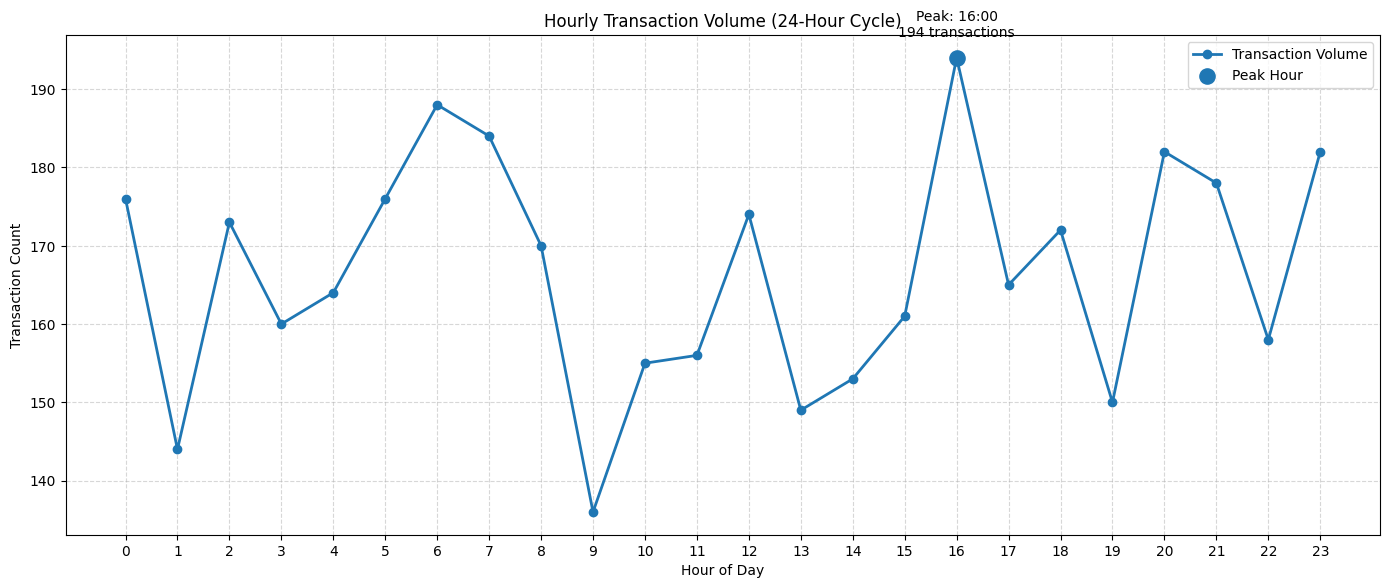

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Peak hour(s) find karo
max_transactions = peak_hour['Transaction_Count'].max()

peak_hours = peak_hour[
    peak_hour['Transaction_Count'] == max_transactions
]

# Line Plot
plt.figure(figsize=(14, 6))

plt.plot(
    peak_hour['Hour'],
    peak_hour['Transaction_Count'],
    marker='o',
    linewidth=2,
    label='Transaction Volume'
)

# Peak hours highlight
plt.scatter(
    peak_hours['Hour'],
    peak_hours['Transaction_Count'],
    s=120,
    zorder=5,
    label='Peak Hour'
)

# Peak hour labels
for _, row in peak_hours.iterrows():
    plt.annotate(
        f"Peak: {int(row['Hour']):02d}:00\n{int(row['Transaction_Count'])} transactions",
        (row['Hour'], row['Transaction_Count']),
        xytext=(0, 15),
        textcoords='offset points',
        ha='center'
    )

# Custom ticks: 0 to 23
plt.xticks(range(24))

# Gridlines
plt.grid(True, linestyle='--', alpha=0.5)

plt.xlabel('Hour of Day')
plt.ylabel('Transaction Count')
plt.title('Hourly Transaction Volume (24-Hour Cycle)')
plt.legend()

plt.tight_layout()
plt.show()

# Histogram with Subplots: Create a $1 \times 2$ subplot displaying:Left: Histogram of Amount_INR with 30 bins.Right: Log-transformed histogram of Amount_INR with vertical lines indicating

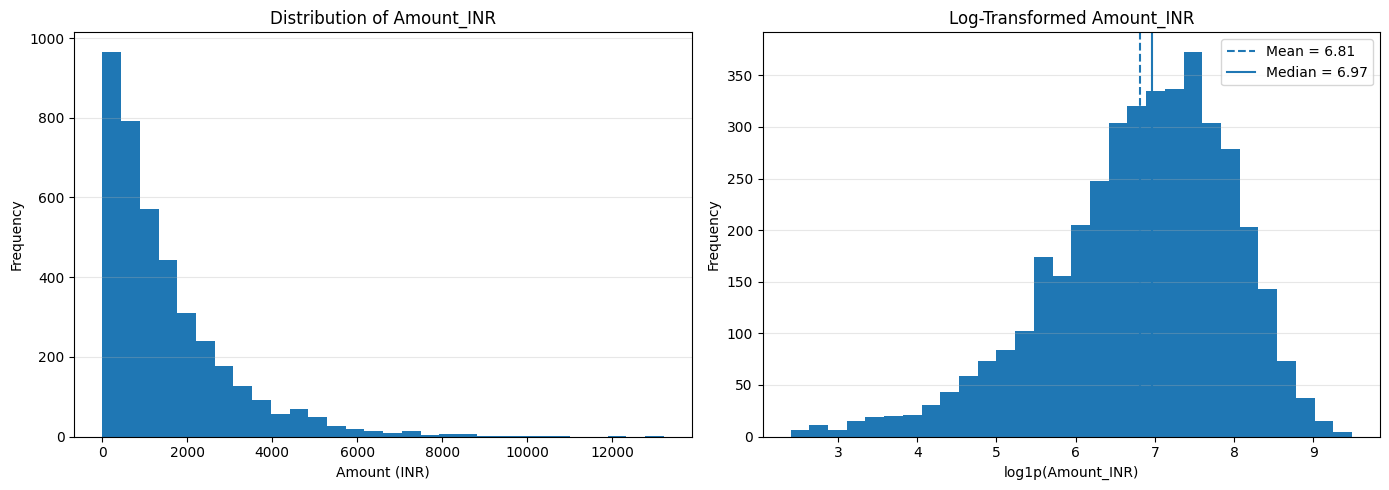

In [25]:


# Log transformation
log_amount = np.log1p(df['Amount_INR'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Original Amount_INR
axes[0].hist(df['Amount_INR'], bins=30)
axes[0].set_title('Distribution of Amount_INR')
axes[0].set_xlabel('Amount (INR)')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', alpha=0.3)

# Right: Log-transformed Amount_INR
axes[1].hist(log_amount, bins=30)

# Mean and median lines
mean_log = log_amount.mean()
median_log = log_amount.median()

axes[1].axvline(mean_log, linestyle='--', label=f'Mean = {mean_log:.2f}')
axes[1].axvline(median_log, linestyle='-', label=f'Median = {median_log:.2f}')

axes[1].set_title('Log-Transformed Amount_INR')
axes[1].set_xlabel('log1p(Amount_INR)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Stacked Bar Chart: Show the proportion of transaction Status (Success, Failed, Reversed) across different Device_Type categories.

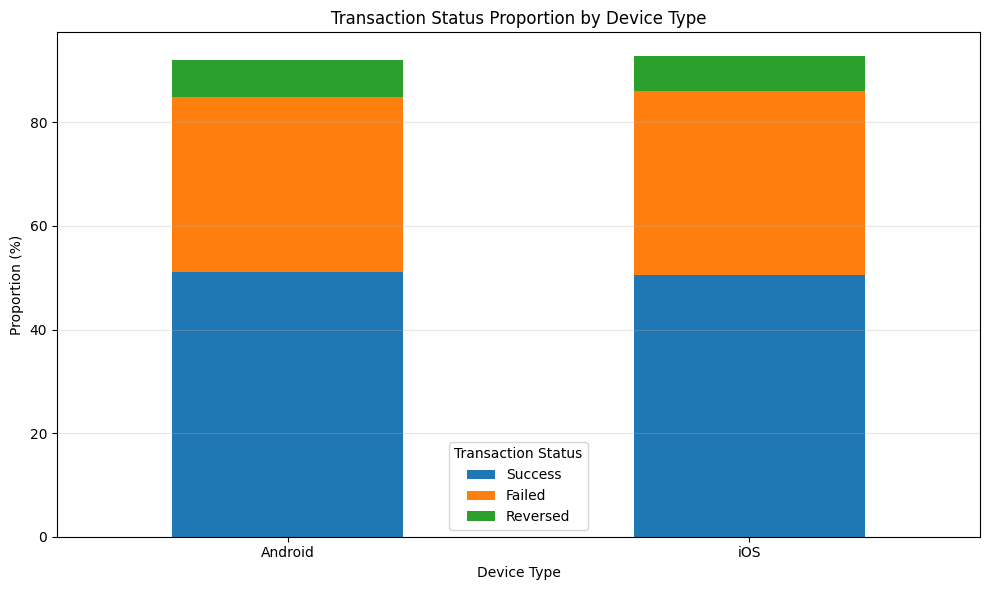

In [27]:

# Count Status for each Device Type
status_counts = pd.crosstab(
    df['Device_Type'],
    df['Status']
)

# Convert counts into percentages
status_percent = status_counts.div(
    status_counts.sum(axis=1),
    axis=0
) * 100

# Stacked bar chart
status_percent[['Success', 'Failed', 'Reversed']].plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('Transaction Status Proportion by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Proportion (%)')
plt.xticks(rotation=0)
plt.legend(title='Transaction Status')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# **Advanced EDA & Statistical Plots (Seaborn)**

# Boxplot / Violin Plot: Visualize the distribution of Response_Time_ms across different UPI_App providers. Which app shows the highest variance?

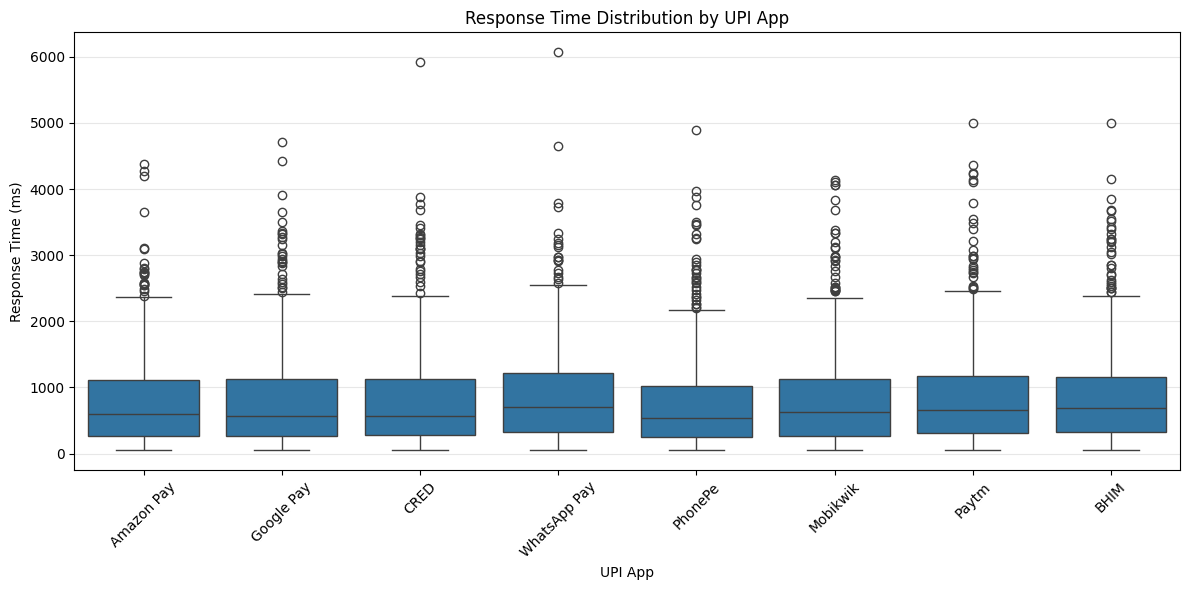

In [28]:

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='UPI_App',
    y='Response_Time_ms'
)

plt.title('Response Time Distribution by UPI App')
plt.xlabel('UPI App')
plt.ylabel('Response Time (ms)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# **Heatmap: Generate an annotated heatmap showing the count of failed transactions broken down by Sender_Bank and Failure_Reason.**

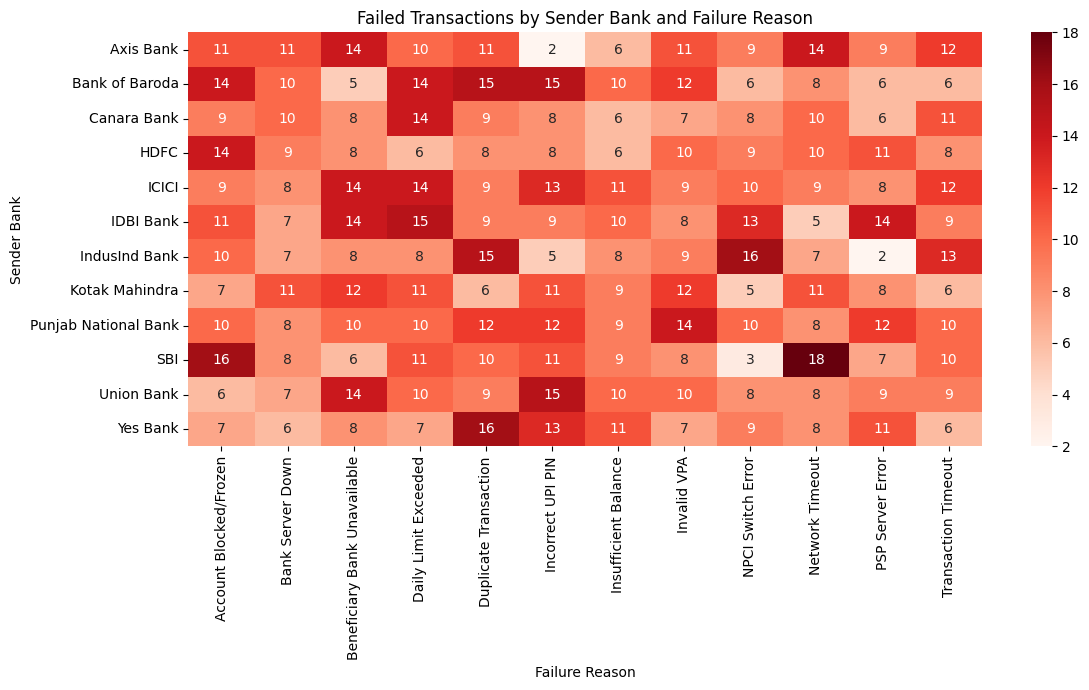

In [30]:

# Failed transactions only
failed_df = df[df['Status'] == 'Failed']

# Count of failed transactions
failure_counts = pd.crosstab(
    failed_df['Sender_Bank'],
    failed_df['Failure_Reason']
)

# Heatmap
plt.figure(figsize=(12, 7))

sns.heatmap(
    failure_counts,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title('Failed Transactions by Sender Bank and Failure Reason')
plt.xlabel('Failure Reason')
plt.ylabel('Sender Bank')

plt.tight_layout()
plt.show()

# Categorical Count Plot: Create a sns.catplot showing failure reasons grouped by Is_Weekend to check if weekends experience different failure modes.

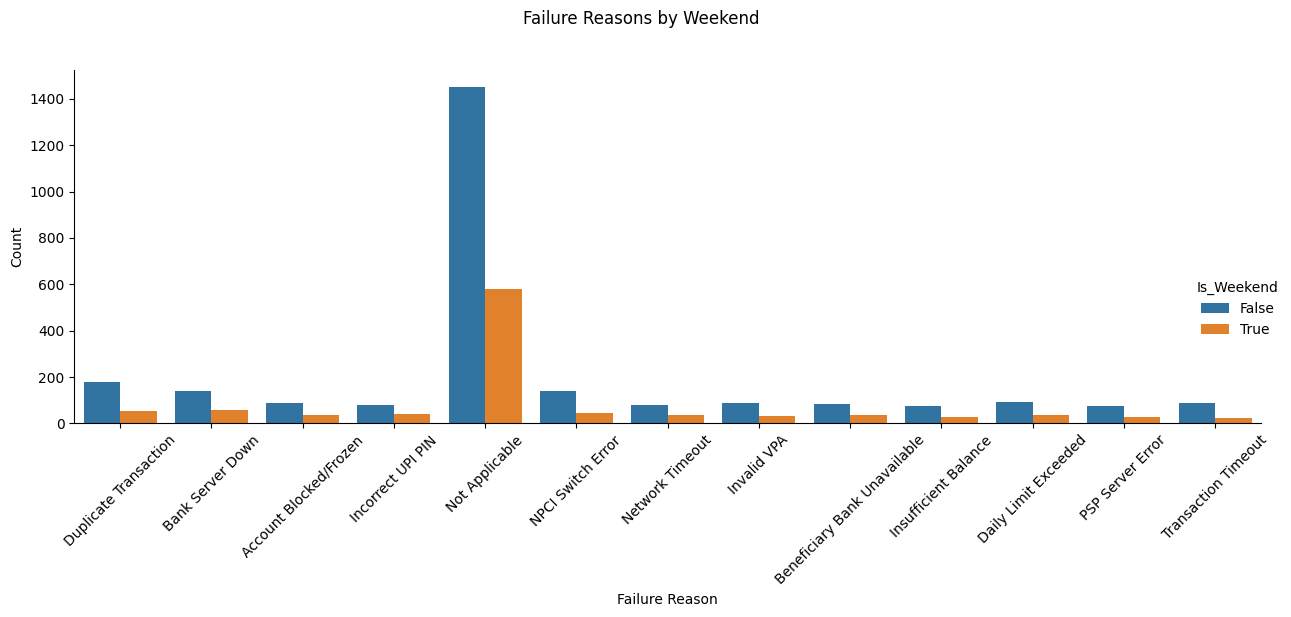

In [39]:
g = sns.catplot(
    data=df,
    x='Failure_Reason',
    hue='Is_Weekend',
    kind='count',
    height=6, aspect=2 # Adjust height and aspect for figure size
)

g.set_axis_labels('Failure Reason', 'Count')
g.set_titles('Is Weekend = {col_name}')

# Apply rotation to x-axis labels on each subplot
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Failure Reasons by Weekend', y=1.02) # Use suptitle for overall title
plt.tight_layout()
plt.show()

# Scatter Plot with Hue: Plot Amount_INR against Response_Time_ms, coloring the points by Status to detect any latency-to-failure correlation.

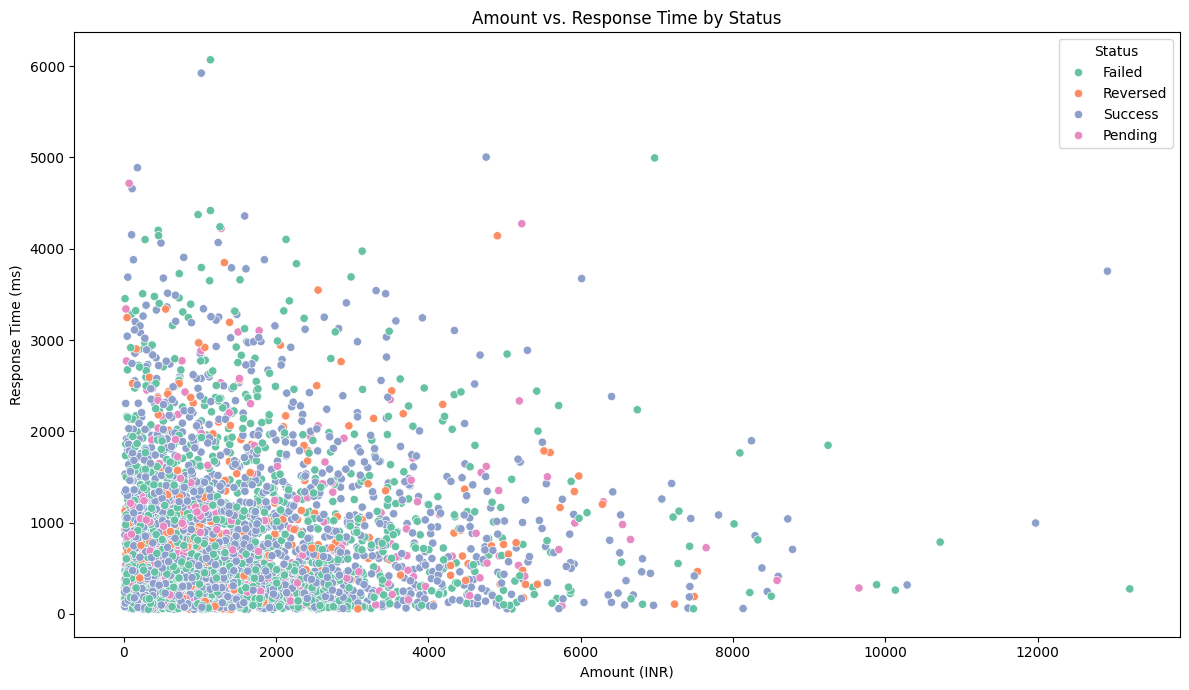

In [41]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x='Amount_INR',
    y='Response_Time_ms',
    hue='Status',
    palette='Set2'
)

plt.title('Amount vs. Response Time by Status')
plt.xlabel('Amount (INR)')
plt.ylabel('Response Time (ms)')
plt.legend(title='Status')

plt.tight_layout()
plt.show()